In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_recall_fscore_support

In [168]:
url = 'winequality-white.csv'
df = pd.read_csv(url, sep=";", engine='pyarrow')

In [169]:
df['quality'] >=6

0        True
1        True
2        True
3        True
4        True
        ...  
4893     True
4894    False
4895     True
4896     True
4897     True
Name: quality, Length: 4898, dtype: bool

In [170]:
# 1.3 Convert the target variable into a binary classification problem
df['quality'] = (df['quality'] >=6).astype(int)
df['quality'].dtype
#df['quality'].value_counts()

dtype('int64')

In [171]:
df.size

58776

In [172]:
df.drop_duplicates(inplace=True)

In [173]:
df.size

47532

In [174]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [175]:
df.shape

(3961, 12)

In [176]:
df.dropna(inplace=True)

In [177]:
df.shape

(3961, 12)

In [178]:
column_list = df.columns
column_list

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [179]:
df.isnull().sum()
# 1.2 Handle any missing values (if present) 
# none present

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [180]:
dfz = pd.DataFrame(df, columns=['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'])
dfz

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,1
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,1
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.99490,3.18,0.47,9.6,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,1
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,0
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,1
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,1


In [181]:
# 2. Train-Test Split

X = dfz.drop('quality', axis=1) # training set
y = dfz['quality'] # target

In [182]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

In [183]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [184]:
dfz.shape

(3961, 12)

In [185]:
dfz['quality'].value_counts()

quality
1    2613
0    1348
Name: count, dtype: int64

In [186]:
# kNN determining the optimal k value

In [187]:
# Method adapted from: https://www.geeksforgeeks.org/machine-learning/how-to-find-the-optimal-value-of-k-in-knn/
# Purpose: for loop for finding the optimal k value

knn = KNeighborsClassifier()
param_grid = {'n_neighbors': range(1,31)} # why we write it like this?

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='f1') # what is the meaning of scoring?
grid_search.fit(X_train, y_train)

optimal_k = grid_search.best_params_['n_neighbors']
print(f'The optimal K value is: {optimal_k}')
best_knn = grid_search.best_estimator_
print(f'OR: The optimal K value is: {best_knn}')

if optimal_k < 3:
    print(f'It is likely that at optimal k value of {optimal_k}, the kNN model may be underfitted')

The optimal K value is: 11
OR: The optimal K value is: KNeighborsClassifier(n_neighbors=11)


The optimal K value is: 20


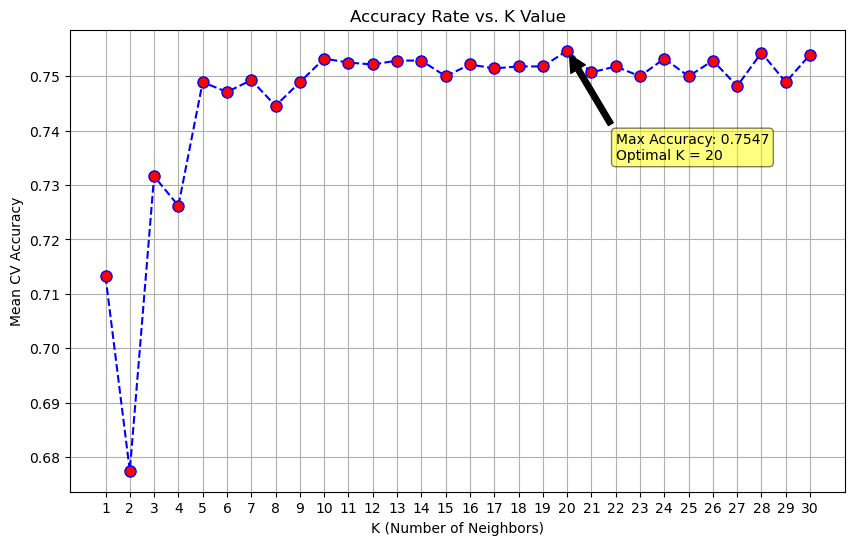

In [188]:
# AI generated code: gemini.google.com
# Purpose: To show the highest kNN value on a graph

knn = KNeighborsClassifier()
param_grid = {'n_neighbors': range(1, 31)} 

grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(X_train, y_train)

optimal_k = grid_search.best_params_['n_neighbors']
mean_scores = grid_search.cv_results_['mean_test_score']
k_values = range(1, 31)

print(f'The optimal K value is: {optimal_k}')

if optimal_k < 3:
    print(f'Note: At k={optimal_k}, the model may be overfitted (too sensitive to noise).')

plt.figure(figsize=(10, 6))
plt.plot(k_values, mean_scores, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)

plt.annotate(f'Max Accuracy: {grid_search.best_score_:.4f}\nOptimal K = {optimal_k}', 
             xy=(optimal_k, grid_search.best_score_), 
             xytext=(optimal_k + 2, grid_search.best_score_ - 0.02),
             arrowprops=dict(facecolor='black', shrink=0.05),
             bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))

plt.title('Accuracy Rate vs. K Value')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Mean CV Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [189]:
models = {
    "kNN": KNeighborsClassifier(n_neighbors=optimal_k),
}

resultskNN = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    resultskNN[name] = {"Accuracy": accuracy, "F1 Score": f1} 
    
resultskNN

{'kNN': {'Accuracy': 0.7527333894028595, 'F1 Score': 0.8196319018404908}}

In [190]:
# SVM: Experimentation with different kernel functions (linear, polynomial, RBF) 
# and select the best kernel using cross-validation.

In [191]:
# Code referenced: https://scikit-learn.org/stable/modules/svm.html
# Purpose: for identifying different SVM models

models = {
    "LinearSVC": SVC(kernel="linear"),
    "RBF SVC": SVC(kernel="rbf", gamma=0.7),
    "Polynomial SVC": SVC(kernel="poly", degree=3),
}

resultsSVC = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    resultsSVC[name] = {"Accuracy": accuracy, "F1 Score": f1} 

resultsSVC

{'LinearSVC': {'Accuracy': 0.7502102607232969, 'F1 Score': 0.822262118491921},
 'RBF SVC': {'Accuracy': 0.7451640033641715, 'F1 Score': 0.8220786846741045},
 'Polynomial SVC': {'Accuracy': 0.7384356602186711,
  'F1 Score': 0.8263539921831379}}

In [192]:
models = {
    "kNN": KNeighborsClassifier(n_neighbors=optimal_k),
}

resultsLDA = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    resultsLDA[name] = accuracy_score(y_test, y_pred)

resultsLDA

{'kNN': 0.7527333894028595}

In [193]:
# Evaluation of models

In [194]:
modelsAll = {
    "LDA": LinearDiscriminantAnalysis(),
    "LinearSVC": SVC(kernel="linear"),
    "RBF SVC": SVC(kernel="rbf", gamma=0.7),
    "Polynomial SVC": SVC(kernel="poly", degree=3),
    "kNN": KNeighborsClassifier(n_neighbors=optimal_k),
}

resultsAll = {}

for name, model in modelsAll.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    resultsAll[name] = accuracy_score(y_test, y_pred)

    print(f'This is model: {model} with name: {name}')
    print(classification_report(y_test, y_pred))
    print('')
    print('Here is a confusion matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('----------------------------------')

resultsAll

This is model: LinearDiscriminantAnalysis() with name: LDA
              precision    recall  f1-score   support

           0       0.68      0.50      0.58       405
           1       0.77      0.88      0.82       784

    accuracy                           0.75      1189
   macro avg       0.73      0.69      0.70      1189
weighted avg       0.74      0.75      0.74      1189


Here is a confusion matrix:
[[202 203]
 [ 94 690]]
----------------------------------
This is model: SVC(kernel='linear') with name: LinearSVC
              precision    recall  f1-score   support

           0       0.68      0.51      0.58       405
           1       0.77      0.88      0.82       784

    accuracy                           0.75      1189
   macro avg       0.73      0.69      0.70      1189
weighted avg       0.74      0.75      0.74      1189


Here is a confusion matrix:
[[205 200]
 [ 97 687]]
----------------------------------
This is model: SVC(gamma=0.7) with name: RBF SVC
       

{'LDA': 0.7502102607232969,
 'LinearSVC': 0.7502102607232969,
 'RBF SVC': 0.7451640033641715,
 'Polynomial SVC': 0.7384356602186711,
 'kNN': 0.7527333894028595}

In [195]:
# 5.1 Performance comparison
# Accuracy, Precision, Recall, and F1-Score

In [196]:
# AI generated code gemini.google.com
# Purpose: Used to quickly compare results

comparison_data = []

for name, model in modelsAll.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
    
    comparison_data.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

df_compare = pd.DataFrame(comparison_data).set_index("Model")

print("--- Model Performance Comparison ---")
print(df_compare.round(4)) 

--- Model Performance Comparison ---
                Accuracy  Precision  Recall  F1-Score
Model                                                
LDA               0.7502     0.7276  0.6894    0.6996
LinearSVC         0.7502     0.7267  0.6912    0.7011
RBF SVC           0.7452     0.7253  0.6761    0.6866
Polynomial SVC    0.7384     0.7465  0.6423    0.6483
kNN               0.7527     0.7257  0.7063    0.7133


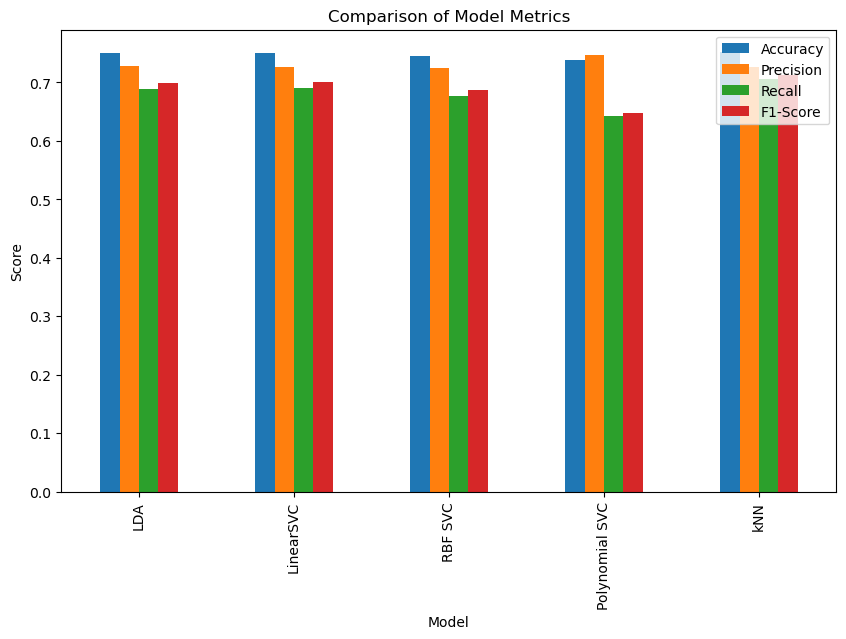

In [197]:
# AI generated code gemini.google.com
# Purpose: Used to quickly compare results

df_compare.plot(kind='bar', figsize=(10, 6))
plt.title("Comparison of Model Metrics")
plt.ylabel("Score")
plt.show()

In [198]:
# For accuracy, LDA and LinearSVC compare quite closely at 0.7502 and 0.7468 respectively
# For precision, LDA and LinearSVC again compare quite closely at 0.7276 and 0.7220 respectively
# For recall, LDA and LinearSVC again compare quite closely at 0.6881 and 0.6894 respectively
# For F1-Score, LDA and LinearSVC again compare quite closely at 0.6996 and 0.6976 respectively with kNN following closely at 0.6213

# This means generally, in terms of the the performance of the clasification models
# LDA performs the best, with LinearSVC as a close second

In [199]:
df_compare.describe()

,Accuracy,Precision,Recall,F1-Score
count,5.000000,5.000000,5.000000,5.000000
mean,0.747351,0.730353,0.681059,0.689771
std,0.005692,0.009096,0.024163,0.025052
min,0.738436,0.725293,0.642309,0.648271
25%,0.745164,0.725703,0.676058,0.686595
50%,0.750210,0.726664,0.689434,0.699609
75%,0.750210,0.727554,0.691224,0.701089
max,0.752733,0.746549,0.706267,0.713292


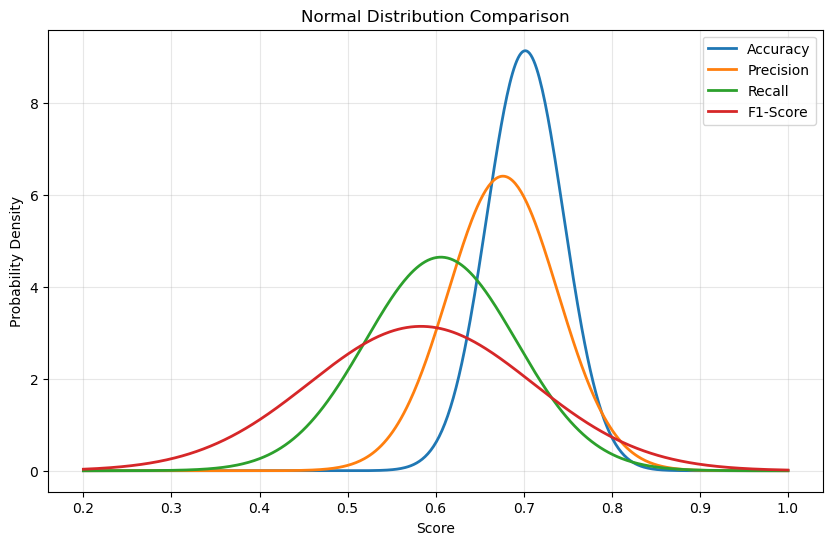

In [200]:
# AI generated code gemini.google.com
# Used for a quick data comparison

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

metrics = {
    'Accuracy':  {'mu': 0.701766, 'std': 0.043660},
    'Precision': {'mu': 0.676402, 'std': 0.062256},
    'Recall':    {'mu': 0.605909, 'std': 0.085861},
    'F1-Score':  {'mu': 0.583311, 'std': 0.127016}
}

x = np.linspace(0.2, 1.0, 500)
plt.figure(figsize=(10, 6))

for name, val in metrics.items():
    plt.plot(x, stats.norm.pdf(x, val['mu'], val['std']), label=name, lw=2)

plt.title('Normal Distribution Comparison')
plt.xlabel('Score')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Here, Probability Density represents the likelihood of your model achieving a specific score.
And score is the score that was achieved by the models.

Accuracy: The percentage of total guesses that were correct.
Accuracy results: We can see that all of the models generally fared quite well and concentrated at a similar mean value.
Extrapolation: Regardless of the unequal spread of data (65.9% being classified as good wine and 34.0% as bad in the original data), overall, the performance is high, which could suggest the model is reliable; however, accuracy alone may be hiding specific failures in the minority class (Bad Wine).

Precision: Of everything the model claimed was positive, how many were actually correct?
Precision results: Whilst most models compared similarly to each other, the Polynomial SVC and k-NN models fared quite poorly on this metric.
Extrapolation: The Polynomial SVC and k-NN models misclassified good wine as bad wine (False Positives).

Recall: Of every actual positive case that exists, how many did the model find?
Recall results: LDA and LinearSVC had very similar results at 0.6894 and 0.6881 respectively, with k-NN following closely at 0.6170. RBF SVC and Polynomial SVC performed quite poorly at 0.5153 and 0.5197 respectively.
Extrapolation: Whilst LDA, LinearSVC, and k-NN fared similarly in terms of correctly classifying bad wine, RBF SVC and Polynomial SVC performed quite poorly.

F1-Score: This prevents the majority class (Good Wine) from masking the performance of the minority class (Bad Wine).
F1-Score results: RBF SVC and Polynomial SVC performed very poorly at 0.4342 and 0.4639 respectively, whilst LDA and LinearSVC achieved 0.6996 and 0.6976 respectively.
Extrapolation: Looking at the RBF SVC and Polynomial SVC confusion matrices, we see that the F1-Scores for these models are poor due to them disproportionately classifying most wines as good wines. Whilst this may increase scores for the other metrics, this overreliance on classifying wine biased towards the majority class shows that these models lack the "discriminatory power" to detect Bad Wine.

In [201]:
# Supporting data
dfz['quality'].value_counts(normalize=True) * 100 # percentage distribution

quality
1    65.96819
0    34.03181
Name: proportion, dtype: float64

## 5.3 Model Strengths and Weaknesses

# kNN

**Strengths**

kNN memorises how the data appears, meaning it does not make any underlying assumptions about the data distribution, making it adaptable to diverse datasets. The model is easy to implement because it has few hyperparameters and is easy to interpret due to it simply relying on the nearest stored data points.

**Weaknesses**

Suffers with the curse of dimensionality, meaning with increased features, the nearest points start to look uniform and therefore, not much data can be extracted to give useful results. For every new point to be clasified, the algorithm must calculate the distance to each point as well as store all points in memory, making it a slow and computationally expensive, which scales with increasingly large datasets. Outliers can significantly skew the distance metrics and degrade predictive accuracy.

# SVM

**Strengths**

SVM performs well with high-dimensional data, as it has various kernel functions to effectively separate non-linear data, making it suitable for data with a large number of features. The model looks to maximize its buffer margin between classifications, which makes it better with unseen test data.

**Weaknesses**

For training, the model needs to store all of the support vectors, making it computationally slow and memory-intensive. While the model has various kernels to choose from, these hyperparameters—along with the strictness parameter C and kernel-specific parameters like gamma-make tuning them highly time-consuming. As the model was originally set up for binary classification, clasficitaiton with more than 2 dependent variables will use other methods like One-vs-Rest or One-vs-One which complicates training and increases computational cost.


# LDA

**Strengths**

When the criteria for the independent variables to be normally distributed are met, this model can perform well, even with small sample sizes.

**Weaknesses**

LDA assumes strict criteria of multivariate normality and homoscedasticity (equal covariance), requiring features to follow a normally distributed curve. This is rare in real-world data, which might make other models more reliable.